### 1. Compensation Structure Analysis
**Author:** Saicharan K

#### Goal
Perform Bivariate Analysis to identify the primary drivers of salary. We will compare categorical variables against the continuous target variable (`salary_in_usd`).

**Key Hypotheses to Test:**
1. **Experience Premium:** Salaries should increase monotonically with experience.
2. **Role Value:** "Data Engineers" and "ML Engineers" should command a premium over "Data Analysts".
3. **Remote Arbitrage:** Remote salaries should be competitive with on-site salaries in the post-2020 era.

In [1]:
#empty cell

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load Data
df = pd.read_csv('../data/ds_salaries_cleaned.csv')

# Define the order for plots to make them logical 
exp_order = ['EN', 'MI', 'SE', 'EX']

print("Data Loaded for Compensation Analysis.")

Data Loaded for Compensation Analysis.


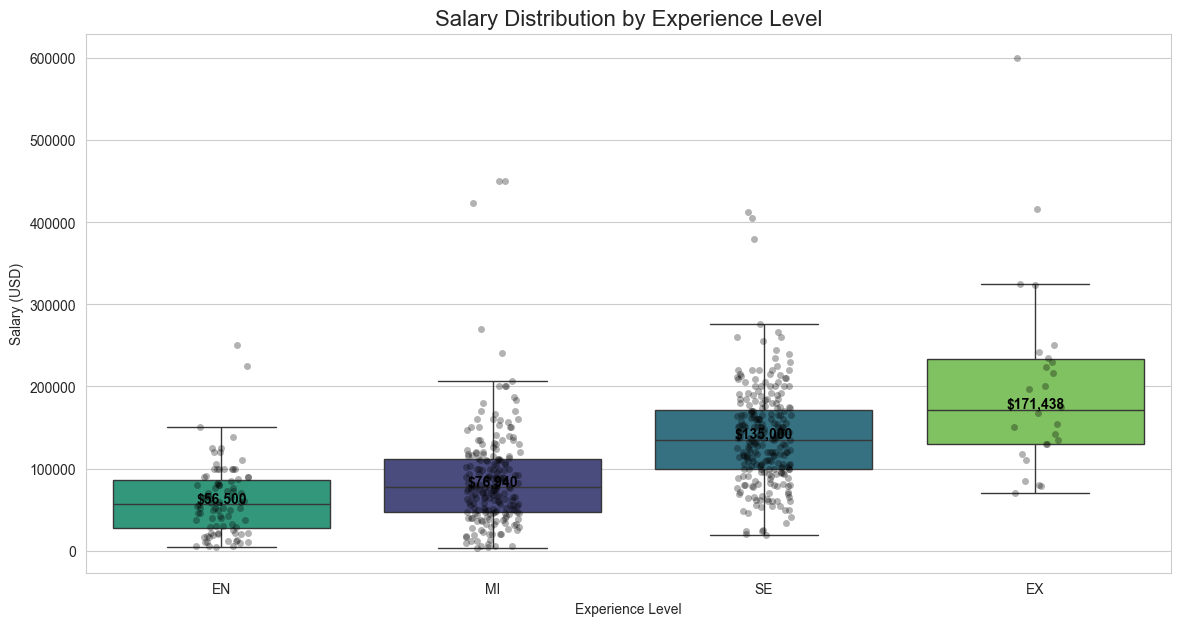

In [10]:
plt.figure(figsize=(14, 7))

# 1. Boxplot 
sns.boxplot(x='experience_level', y='salary_in_usd', hue='experience_level',
            data=df, order=exp_order, palette='viridis', showfliers=False, legend=False)

# 2. Stripplot 
sns.stripplot(x='experience_level', y='salary_in_usd', data=df, 
              order=exp_order, color='black', alpha=0.3, jitter=True)

plt.title('Salary Distribution by Experience Level', fontsize=16)
plt.ylabel('Salary (USD)')
plt.xlabel('Experience Level')

# Add Median annotations
medians = df.groupby(['experience_level'])['salary_in_usd'].median()
for i, level in enumerate(exp_order):
    if level in medians.index:
        plt.text(i, medians[level] + 2000, f"${medians[level]:,.0f}", 
                 horizontalalignment='center', color='black', weight='bold')

plt.show()

### 2. Job Role Premium
We analyze the salary differences between the 4 standardized job categories.

**Hypothesis:** Specialized engineering roles (ML Engineer, Data Engineer) should command a higher median salary than generalist roles (Data Analyst).

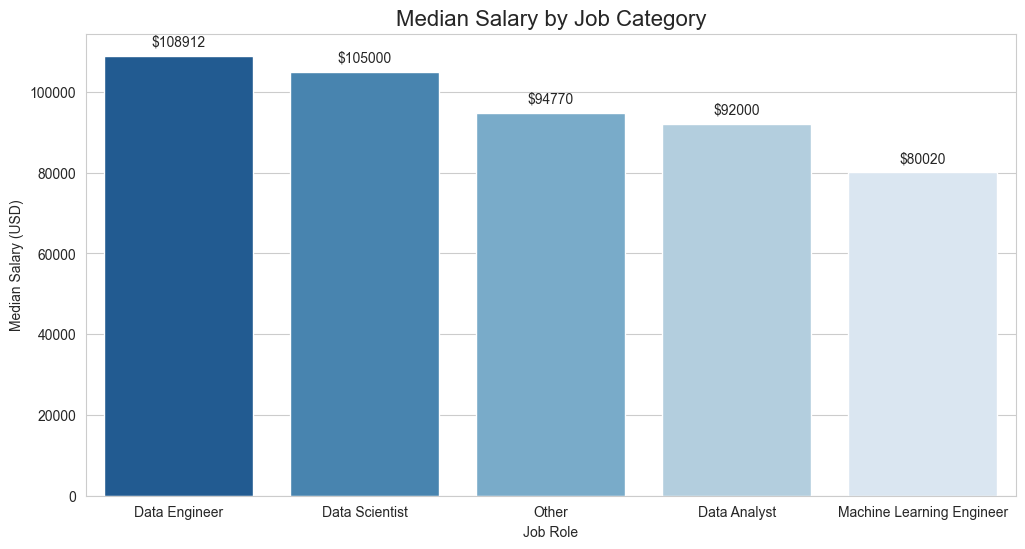

In [11]:
# Calculate median salary per job category
role_salary = df.groupby('job_category')['salary_in_usd'].median().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))

# Barplot 
ax = sns.barplot(x='job_category', y='salary_in_usd', hue='job_category',
                 data=role_salary, palette='Blues_r', legend=False)

plt.title('Median Salary by Job Category', fontsize=16)
plt.ylabel('Median Salary (USD)')
plt.xlabel('Job Role')

# Add labels on top of bars
for i in ax.containers:
    ax.bar_label(i, fmt='$%.0f', padding=5)

plt.show()

### 3. The Remote Work Arbitrage
Does working remotely impact compensation?

**Hypothesis:** Fully remote roles (100) are competitive with On-Site (0) roles, while Hybrid (50) roles might show lower compensation due to local market constraints.

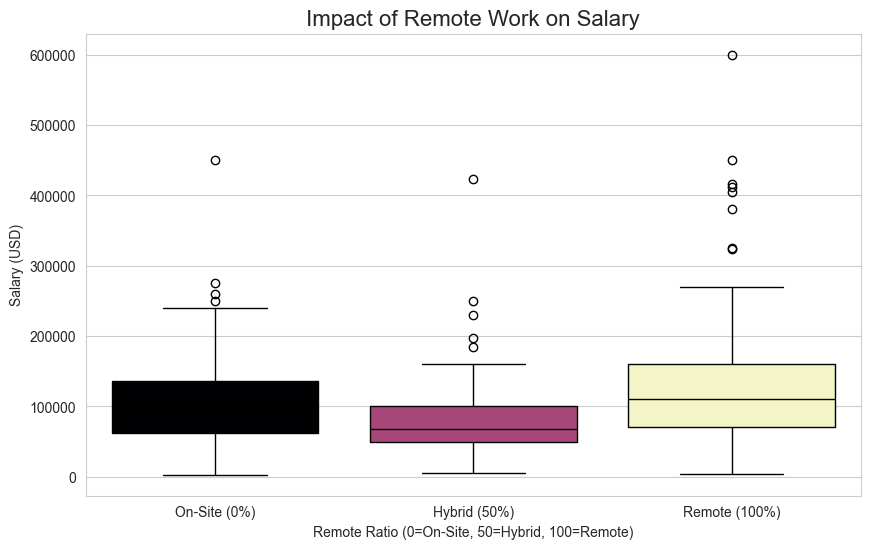

,count,mean,50%
remote_ratio,,,
0,121.00,105785.40,98158.00
50,98.00,80721.90,68010.50
100,346.00,120763.19,110712.50


In [12]:
plt.figure(figsize=(10, 6))

# Boxplot comparing Remote Types
sns.boxplot(x='remote_ratio', y='salary_in_usd', hue='remote_ratio',
            data=df, palette='magma', legend=False)

plt.title('Impact of Remote Work on Salary', fontsize=16)
plt.ylabel('Salary (USD)')
plt.xlabel('Remote Ratio (0=On-Site, 50=Hybrid, 100=Remote)')
plt.xticks([0, 1, 2], ['On-Site (0%)', 'Hybrid (50%)', 'Remote (100%)'])

plt.show()

# Print specific numbers to confirm
remote_stats = df.groupby('remote_ratio')['salary_in_usd'].describe()[['count', 'mean', '50%']]
display(remote_stats)

In [ ]:
# end of notebook 4 ---